# Dataset Creation

# Exam Dataset Creation

## Setup

In [1]:
from openai import OpenAI
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.metrics.pairwise import cosine_distances
import uuid
import json
from pathlib import Path
from utils import BASE_DIR, INPUT_DIR, PROMPTS_DIR, OUTPUTS_DIR, API_INPUT_DIR, API_OUTPUT_DIR, API_JOBS_DIR, create_prompt, create_batch_input_file, \
    send_input_to_api, wait_for_batch_completion, retrieve_api_output, output_jsonl_to_dataframe, run_whole_batch_process

API_KEY = os.getenv("OPENAI_API_KEY_UNIVERSITY")
client = OpenAI(api_key=API_KEY)

## Helper Functions

In [2]:
def load_df(file_name: str, file_dir: Path=INPUT_DIR) -> pd.DataFrame:
    file_path = file_dir / file_name
    if file_path.suffix == ".pkl":
        return pd.read_pickle(file_path)
    elif file_path.suffix == ".xlsx":
        return pd.read_excel(file_path)
    elif file_path.suffix == ".csv":
        return pd.read_csv(file_path)
    else:
        raise ValueError("Unsupported file format")
    
def merge_dfs(df1: pd.DataFrame, df2: pd.DataFrame, on_left: str="id", on_right="custom_id", how: str="left", df1_columns=None, df2_columns=None) -> pd.DataFrame:
    if df1_columns is not None:
        df1 = df1[df1_columns + [on_left]]
    if df2_columns is not None:
        df2 = df2[df2_columns + [on_right]]
    merged_df = pd.merge(df1, df2, left_on=on_left, right_on=on_right, how=how, suffixes=('_left', '_right'))
    return merged_df

### Taxonomy

In [3]:
def flatten_taxonomy(tax, level0=None, level1=None):
    rows = []
    if isinstance(tax, dict):
        for k, v in tax.items():
            if level0 is None:
                rows += flatten_taxonomy(v, level0=k, level1=None)
            elif level1 is None:
                rows += flatten_taxonomy(v, level0=level0, level1=k)
            else:
                rows += flatten_taxonomy(v, level0=level0, level1=level1)
    elif isinstance(tax, (list, tuple, set)):
        for item in tax:
            rows.append({"Level0": level0, "Level1": level1, "Label": item})
    else:
        rows.append({"Level0": level0, "Level1": level1, "Label": tax})
    return rows

## Read Workshop DF

In [4]:
# translated_questions_df = pd.read_pickle(INPUT_DIR / "translated_questions_dataset.pkl")
# translated_questions_df.to_excel(INPUT_DIR / "translated_questions_dataset.xlsx", index=False)

In [5]:
# # filter out rows where 'answer_in_hebrew' is NaN or == 'na' and save as csv and excel
# filtered_df = translated_questions_df.dropna(subset=['answer_in_hebrew'])
# filtered_df = filtered_df[filtered_df['answer_in_hebrew'].str.lower() != 'na']
# filtered_df.to_csv(INPUT_DIR / "filtered_translated_questions_dataset.csv", index=False)
# filtered_df.to_excel(INPUT_DIR / "filtered_translated_questions_dataset.xlsx", index=False)

In [6]:
# # sample randomly 100 rows from the filtered dataframe, specifically 'answer_in_hebrew' column, shuffle and save as csv in OUTPUTS_DIR
# sampled_df = filtered_df['answer_in_hebrew'].sample(n=100, random_state=42).reset_index(drop=True)
# sampled_df.to_csv(OUTPUTS_DIR / "sampled_translated_questions_dataset.csv", index=False)

# # do the same for 'question_in_hebrew' column
# sampled_questions_df = filtered_df['question_in_hebrew'].sample(n=100, random_state=42).reset_index(drop=True)
# sampled_questions_df.to_csv(OUTPUTS_DIR / "sampled_translated_questions_questions_dataset.csv", index=False)

In [7]:
# # filtered_df.columns: ['question_type', 'has_solution', 'exam_year', 'semester', 'moed', 'question_number', 'url', 'data_resource', 'points',
# # 'question_translation_latex', 'multiple_choice_answer', 'answer_translation_latex', 'number_of_possible_answers', 'topics_covered', 'dataset', 'translated_separately',
# # 'question_in_hebrew', 'answer_in_hebrew', 'orig_answer_in_eng', 'should_translate', 'question_id', 'comments']

# # display distinct values of year, semester, moed
# filtered_df['semester'] = filtered_df['semester'].str.upper()
# filtered_df['moed'] = filtered_df['moed'].str.upper()
# filtered_df['exam_year'] = filtered_df['exam_year'].astype(int)
# filtered_df.sort_values(by=['exam_year', 'semester', 'moed'], inplace=True)
# display(filtered_df[['exam_year', 'semester', 'moed']].drop_duplicates().reset_index(drop=True))
# # save the above as excel in OUTPUTS_DIR
# filtered_df[['exam_year', 'semester', 'moed']].drop_duplicates().reset_index(drop=True).to_excel(OUTPUTS_DIR / "distinct_exam_years_semesters_moeds.xlsx", index=False)

In [8]:
# # add uuid as str to filtered_df as 'uuid' column and save back to the same excel file
# filtered_df['uuid'] = [str(uuid.uuid4()) for _ in range(len(filtered_df))]
# filtered_df.to_excel(INPUT_DIR / "filtered_translated_questions_dataset_with_uuid.xlsx", index=False)

## Run Batching

### Translate

In [11]:
df = load_df("exams_df.xlsx")
run_whole_batch_process("question_translation", "translation_question", df, "question_hebrew")
run_whole_batch_process("solution_translation", "translation_answer", df, "solution_hebrew")

Sending batch input file to API: c:\projects\LLMsForEducation\batch_files\input\question_translation_input.jsonl
✅ Job created: batch_69826c47c2e881909bba42e0eff87a04
   Info saved to: c:\projects\LLMsForEducation\batch_files\job\question_translation_job.json
Batch job batch_69826c47c2e881909bba42e0eff87a04 status: validating. Checking again in 30 seconds...
Batch job batch_69826c47c2e881909bba42e0eff87a04 status: in_progress. Checking again in 30 seconds...
Batch job batch_69826c47c2e881909bba42e0eff87a04 status: in_progress. Checking again in 30 seconds...
Batch job batch_69826c47c2e881909bba42e0eff87a04 status: in_progress. Checking again in 30 seconds...
Batch job batch_69826c47c2e881909bba42e0eff87a04 status: in_progress. Checking again in 30 seconds...
Batch job batch_69826c47c2e881909bba42e0eff87a04 status: in_progress. Checking again in 30 seconds...
Batch job batch_69826c47c2e881909bba42e0eff87a04 status: in_progress. Checking again in 30 seconds...
Batch job batch_69826c47c2e

,id,custom_id,response,error
0,batch_req_6982897e2db481908aaa3524b5f8d3bf,2022aa1a,"{'status_code': 200, 'request_id': '81520d7f-a...",None
1,batch_req_6982897e1c808190a5150b9a7dc9fc46,2022aa1b,"{'status_code': 200, 'request_id': '0b91369a-5...",None
2,batch_req_6982897e2c4081908bbe4f6c235b0be3,2022aa2a,"{'status_code': 200, 'request_id': 'cc480366-e...",None
3,batch_req_6982897e32b0819082b6df2633d02a5b,2022aa2b,"{'status_code': 200, 'request_id': 'ba26af21-6...",None
4,batch_req_6982897ee6ec81909241fde39b9141dc,2022aa3a,"{'status_code': 200, 'request_id': 'a025feff-7...",None
...,...,...,...,...
292,batch_req_6982898fb8d08190be95010299131a18,2014ab2-d,"{'status_code': 200, 'request_id': '455e23a8-b...",None
293,batch_req_6982898fd0908190b4dbe294edfe7ac7,2014ab3,"{'status_code': 200, 'request_id': 'f8d74776-9...",None
294,batch_req_6982898fdc9081908bef05bb82d9500d,2014ab4-a,"{'status_code': 200, 'request_id': 'eed258cb-4...",None
295,batch_req_6982899004588190854d72233706f40b,2014ab4-b,"{'status_code': 200, 'request_id': 'a66b45d3-7...",None


In [ ]:
df_translated_questions = output_jsonl_to_dataframe("question_translation_output")
df_translated_solutions = output_jsonl_to_dataframe("solution_translation_output")

extract_answer_text = lambda response: (
    response.get("body", {})
            .get("choices", [{}])[0]
            .get("message", {})
            .get("content")
    if isinstance(response, dict) else None
)

df_translated_questions['answer_text'] = df_translated_questions['response'].apply(extract_answer_text)
df_translated_solutions['answer_text'] = df_translated_solutions['response'].apply(extract_answer_text)

df_with_translations = merge_dfs(df, df_translated_questions, on_left="id", on_right="custom_id", how="left", df2_columns=["answer_text"]).rename(columns={"answer_text": "question_english"}).drop(columns=['custom_id'])
df_with_translations = merge_dfs(df_with_translations, df_translated_solutions, on_left="id", on_right="custom_id", how="left", df2_columns=["answer_text"]).rename(columns={"answer_text": "solution_english"}).drop(columns=['custom_id'])

In [18]:
df_with_translations.to_excel(OUTPUTS_DIR / "exams_with_translations.xlsx", index=False)
df_with_translations.head()

,id,year,semester,moed,question,section,points,question_hebrew,solution_hebrew,avg_score,std_score,max_score,avg_score_norm,std_score_norm,question_english,custom_id_left,solution_english,custom_id_right
0,2022aa1a,2022,a,a,1,a,10.0,"מגיעים מפתחות שונים $a_{1},a_{2},...,a_{n}$ (ש...",נאתחל טבלת hash בגודל $O(n)$. שמגיע איבר נבדוק...,8.154762,1.551963,10.0,81.54762,15.51963,"Distinct keys $a_{1}, a_{2}, \ldots, a_{n}$ (w...",2022aa1a,Initialize a hash table of size $O(n)$. When a...,2022aa1a
1,2022aa1b,2022,a,a,1,b,10.0,"מגיעים מפתחות שונים $a_{1},a_{2},...,a_{n}$ (ש...",נשתמש perfect hashing בגודל $O(n)$ שתכיל את כל...,7.789683,2.584948,10.0,77.89683,25.84948,"Distinct keys $a_{1},a_{2},\ldots,a_{n}$ (inte...",2022aa1b,We use perfect hashing of size $O(n)$ that con...,2022aa1b
2,2022aa2a,2022,a,a,2,a,10.0,הבהרה: בשני הסעיפים מותר להשתמש באלגוריתם למצי...,בסעיף זה נפעל על האיברים ומשקליהם כזוגות סדורי...,5.650794,2.988915,10.0,56.50794,29.88915,"Clarification: In both parts, you may use a li...",2022aa2a,In this part we treat the elements and their w...,2022aa2a
3,2022aa2b,2022,a,a,2,b,10.0,הבהרה: בשני הסעיפים מותר להשתמש באלגוריתם למצי...,פתרון הסעיף הקודם: בסעיף זה נפעל על האיברים ומ...,6.396825,3.099102,10.0,63.96825,30.99102,Clarification: In both parts you may use a lin...,2022aa2b,Solution to the previous part: In this section...,2022aa2b
4,2022aa3a,2022,a,a,3,a,10.0,נתון מערך בגודל המכיל n איברים שונים זה מזה. ב...,נאתחל מערך פלט בגודל n. נשים לב שהאיבר המינימל...,7.948413,3.164993,10.0,79.48413,31.64993,Given an array of size \(n\) containing \(n\) ...,2022aa3a,Initialize an output array of size $n$. Note t...,2022aa3a


### Labeling

In [4]:
# read the above excel file
df_with_translations = pd.read_excel(OUTPUTS_DIR / "exams_with_translations.xlsx")

In [ ]:
df_labeled_subject = run_whole_batch_process("label_subject", "label_subject", df_with_translations, "solution_english", system_prompt_filename="labeling_system_prompt_subject")
df_labeled_task_type = run_whole_batch_process("label_task_type", "label_task_type", df_with_translations, "question_english", system_prompt_filename="labeling_system_prompt_task_type")

Batch job output retrieved for ID: batch_69ab1aa5ea248190b3d7addad634ac85, output file saved at: c:\projects\LLMsForEducation\batch_files\output\label_subject_output.jsonl
Sending batch input file to API: c:\projects\LLMsForEducation\batch_files\input\label_task_type_input.jsonl
✅ Job created: batch_69ab2d6ea33c8190a447123ca6e55ec5
   Info saved to: c:\projects\LLMsForEducation\batch_files\job\label_task_type_job.json
Batch job batch_69ab2d6ea33c8190a447123ca6e55ec5 status: validating. Checking again in 30 seconds...
Batch job batch_69ab2d6ea33c8190a447123ca6e55ec5 status: validating. Checking again in 30 seconds...
Batch job batch_69ab2d6ea33c8190a447123ca6e55ec5 status: validating. Checking again in 30 seconds...
Batch job batch_69ab2d6ea33c8190a447123ca6e55ec5 status: in_progress. Checking again in 30 seconds...
Batch job batch_69ab2d6ea33c8190a447123ca6e55ec5 status: in_progress. Checking again in 30 seconds...
Batch job batch_69ab2d6ea33c8190a447123ca6e55ec5 status: in_progress. C

In [ ]:
# retrieve_api_output("label_subject_job", "label_subject_output")    
# retrieve_api_output("label_task_type_job", "label_task_type_output")
# df_labeled_subject = output_jsonl_to_dataframe("label_subject_output")
# df_labeled_task_type = output_jsonl_to_dataframe("label_task_type_output")
# df_labeled_subject['answer_text'] = df_labeled_subject['response'].apply(extract_answer_text)
# df_labeled_task_type['answer_text'] = df_labeled_task_type['response'].apply(extract_answer_text)

df_with_labels = merge_dfs(df_with_translations, df_labeled_subject, on_left="id", on_right="custom_id", how="left", df2_columns=["answer_text"]).rename(columns={"answer_text": "subject_labels"})
df_with_labels = df_with_labels.drop(columns=['custom_id'])
df_with_labels = merge_dfs(df_with_labels, df_labeled_task_type, on_left="id", on_right="custom_id", how="left", df2_columns=["answer_text"]).rename(columns={"answer_text": "task_type_labels"})
df_with_labels = df_with_labels.drop(columns=['custom_id'])


In [10]:
# df_with_labels = df_with_labels.drop(columns=['custom_id_left', 'custom_id_right', 'custom_id'])
df_with_labels.to_excel(OUTPUTS_DIR / "exams_with_translations_and_labels.xlsx", index=False)
df_with_labels.head()

,id,year,semester,moed,question,section,points,question_hebrew,solution_hebrew,avg_score,std_score,max_score,avg_score_norm,std_score_norm,question_english,custom_id_left,solution_english,custom_id_right,subject_labels,task_type_labels
0,2022aa1a,2022,a,a,1,a,10.0,"מגיעים מפתחות שונים $a_{1},a_{2},...,a_{n}$ (ש...",נאתחל טבלת hash בגודל $O(n)$. שמגיע איבר נבדוק...,8.154762,1.551963,10.0,81.54762,15.51963,"Distinct keys $a_{1}, a_{2}, \ldots, a_{n}$ (w...",2022aa1a,Initialize a hash table of size $O(n)$. When a...,2022aa1a,"{\n ""subject_tags"": [""Hash Tables"", ""Expected...","{\n ""primary_task_type"": ""DS_DESIGN"",\n ""sec..."
1,2022aa1b,2022,a,a,1,b,10.0,"מגיעים מפתחות שונים $a_{1},a_{2},...,a_{n}$ (ש...",נשתמש perfect hashing בגודל $O(n)$ שתכיל את כל...,7.789683,2.584948,10.0,77.89683,25.84948,"Distinct keys $a_{1},a_{2},\ldots,a_{n}$ (inte...",2022aa1b,We use perfect hashing of size $O(n)$ that con...,2022aa1b,"{\n ""subject_tags"": [""Hash Tables"", ""Expected...","{\n ""primary_task_type"": ""DS_DESIGN"",\n ""sec..."
2,2022aa2a,2022,a,a,2,a,10.0,הבהרה: בשני הסעיפים מותר להשתמש באלגוריתם למצי...,בסעיף זה נפעל על האיברים ומשקליהם כזוגות סדורי...,5.650794,2.988915,10.0,56.50794,29.88915,"Clarification: In both parts, you may use a li...",2022aa2a,In this part we treat the elements and their w...,2022aa2a,"{\n ""subject_tags"": [""Arrays"", ""Selection Pro...","{\n ""primary_task_type"": ""ALG_DESIGN"",\n ""se..."
3,2022aa2b,2022,a,a,2,b,10.0,הבהרה: בשני הסעיפים מותר להשתמש באלגוריתם למצי...,פתרון הסעיף הקודם: בסעיף זה נפעל על האיברים ומ...,6.396825,3.099102,10.0,63.96825,30.99102,Clarification: In both parts you may use a lin...,2022aa2b,Solution to the previous part: In this section...,2022aa2b,"{\n ""subject_tags"": [""Arrays"", ""Selection Pro...","{\n ""primary_task_type"": ""ALG_DESIGN"",\n ""se..."
4,2022aa3a,2022,a,a,3,a,10.0,נתון מערך בגודל המכיל n איברים שונים זה מזה. ב...,נאתחל מערך פלט בגודל n. נשים לב שהאיבר המינימל...,7.948413,3.164993,10.0,79.48413,31.64993,Given an array of size \(n\) containing \(n\) ...,2022aa3a,Initialize an output array of size $n$. Note t...,2022aa3a,"{\n ""subject_tags"": [""Binary Heaps"", ""Big-O""]\n}","{\n ""primary_task_type"": ""ALG_DESIGN"",\n ""se..."


### Solving Questions

In [34]:
# duplicate each row in df_with_labels n times, add a column 'duplicate_id' with values 0, 1, ..., n-1
n = 7
# repeat each row n times
df_dup = df_with_labels.loc[df_with_labels.index.repeat(n)].copy()

# add duplicate_id: 0,1,2 for each original row
df_dup["duplicate_id"] = df_dup.groupby(level=0).cumcount()

# create rep_id = id + "_" + duplicate_id
df_dup["rep_id"] = df_dup["id"].astype(str) + "_" + df_dup["duplicate_id"].astype(str)

# (optional) reset index if you want a clean sequential index
df_dup = df_dup.reset_index(drop=True)


In [42]:
df_solutions = run_whole_batch_process("solve_problem_o3", "solve_suffix", df_dup, "question_english", id_column="rep_id", model="o3")

Batch job batch_69839cde8b74819082ba9e4bb2c185ed status: in_progress. Checking again in 30 seconds...
Batch job batch_69839cde8b74819082ba9e4bb2c185ed status: in_progress. Checking again in 30 seconds...
Batch job batch_69839cde8b74819082ba9e4bb2c185ed status: in_progress. Checking again in 30 seconds...
Batch job batch_69839cde8b74819082ba9e4bb2c185ed status: in_progress. Checking again in 30 seconds...
Batch job batch_69839cde8b74819082ba9e4bb2c185ed status: in_progress. Checking again in 30 seconds...
Batch job batch_69839cde8b74819082ba9e4bb2c185ed status: in_progress. Checking again in 30 seconds...
Batch job batch_69839cde8b74819082ba9e4bb2c185ed status: in_progress. Checking again in 30 seconds...
Batch job batch_69839cde8b74819082ba9e4bb2c185ed status: in_progress. Checking again in 30 seconds...
Batch job batch_69839cde8b74819082ba9e4bb2c185ed status: in_progress. Checking again in 30 seconds...
Batch job batch_69839cde8b74819082ba9e4bb2c185ed status: in_progress. Checking aga

WindowsPath('c:/projects/LLMsForEducation/batch_files/output/solve_problem_o3_output.jsonl')

In [44]:
df_solutions = output_jsonl_to_dataframe("solve_problem_o3_output")
df_with_solutions = merge_dfs(df_dup, df_solutions, on_left="rep_id", on_right="custom_id", how="left", df2_columns=["answer_text", "reasoning_tokens", "total_tokens", "completion_tokens"]).rename(columns={
    "answer_text": "model_solution"}).drop(columns=['custom_id_left'])
df_solutions.head()
df_solutions['reasoning_tokens'].value_counts()


,batch_id,custom_id,status_code,model,answer_text,prompt_tokens,completion_tokens,total_tokens,reasoning_tokens,cached_tokens
0,batch_req_6983a12372608190bd948306842a1c14,2022aa1a_0,200,o3-2025-04-16,Let T = K³ and pre–compute the integer K = ³√T...,190,1057,1247,832,0
1,batch_req_6983a1237a648190a9622ebc4fbb2e4d,2022aa1a_1,200,o3-2025-04-16,"Let c = ³√T (an integer, known in advance). \...",190,857,1047,640,0
2,batch_req_6983a12397f88190b72fbce64113e62d,2022aa1a_2,200,o3-2025-04-16,Pre-compute k = ³√T (an integer because T is a...,190,959,1149,768,0
3,batch_req_6983a12373508190b6d43c19e4bb8748,2022aa1a_3,200,o3-2025-04-16,"Let T = b³, where b = ∛T is pre-computed once....",190,573,763,384,0
4,batch_req_6983a1237d708190b2e8015a119154a4,2022aa1a_4,200,o3-2025-04-16,"Let c = T^(1/3) (an integer, known once at the...",190,591,781,384,0


### Grading

In [47]:
df_with_solutions['answer_grading_suffix'] = 'student answer:\n' + df_with_solutions['model_solution'] + '\ntrue solution:\n' + df_with_solutions['solution_english']
run_whole_batch_process("grade_answer_o3", "grader", df_with_solutions, "answer_grading_suffix", id_column="rep_id")

Sending batch input file to API: c:\projects\LLMsForEducation\batch_files\input\grade_answer_o3_input.jsonl
✅ Job created: batch_6983a587c9348190adddb5624c5b744f
   Info saved to: c:\projects\LLMsForEducation\batch_files\job\grade_answer_o3_job.json
Batch job batch_6983a587c9348190adddb5624c5b744f status: validating. Checking again in 30 seconds...
Batch job batch_6983a587c9348190adddb5624c5b744f status: in_progress. Checking again in 30 seconds...
Batch job batch_6983a587c9348190adddb5624c5b744f status: in_progress. Checking again in 30 seconds...
Batch job batch_6983a587c9348190adddb5624c5b744f status: in_progress. Checking again in 30 seconds...
Batch job batch_6983a587c9348190adddb5624c5b744f status: in_progress. Checking again in 30 seconds...
Batch job batch_6983a587c9348190adddb5624c5b744f status: in_progress. Checking again in 30 seconds...
Batch job batch_6983a587c9348190adddb5624c5b744f status: in_progress. Checking again in 30 seconds...
Batch job batch_6983a587c9348190adddb

,id,custom_id,response,error
0,batch_req_6983afc1ee1081908537b034bff1672d,2022aa1a_0,"{'status_code': 200, 'request_id': 'fe3f59a0-7...",None
1,batch_req_6983afc0be648190bfddee686dbc88bf,2022aa1a_1,"{'status_code': 200, 'request_id': 'fc2be4a1-5...",None
2,batch_req_6983afc0b45c8190bbf7b934b6bb754c,2022aa1a_2,"{'status_code': 200, 'request_id': 'b616d0bd-6...",None
3,batch_req_6983afc0cc308190882613a05ccdd1cc,2022aa1a_3,"{'status_code': 200, 'request_id': '707bb851-1...",None
4,batch_req_6983afc0a1c08190826757e1d0071415,2022aa1a_4,"{'status_code': 200, 'request_id': 'dd199983-9...",None
...,...,...,...,...
2074,batch_req_6983b0e5097c8190b8bc3668dd6eb4b0,2014ab4-c_2,"{'status_code': 200, 'request_id': 'ded21675-a...",None
2075,batch_req_6983b0e54cd88190b1eeb4fda9fc4c65,2014ab4-c_3,"{'status_code': 200, 'request_id': '3a7dfd10-5...",None
2076,batch_req_6983b0e559988190a428fa871f20c42c,2014ab4-c_4,"{'status_code': 200, 'request_id': '677a5e74-4...",None
2077,batch_req_6983b0e55fa48190ad782418a5666aa9,2014ab4-c_5,"{'status_code': 200, 'request_id': '1ac59235-5...",None


In [50]:
df_with_solutions = df_with_solutions.drop(columns=['answer_grading_suffix'])
df_grades = output_jsonl_to_dataframe("grade_answer_o3_output")
final_df_dup = merge_dfs(df_with_solutions, df_grades, on_left="rep_id", on_right="custom_id", how="left", df2_columns=["answer_text"]).rename(columns={"answer_text": "answer_grade"}).drop(columns=['custom_id'])
final_df_dup['grade'] = final_df_dup['answer_grade'].str.extract(r'Grade:\s*(\w+)')
final_df_dup.head()

,id,year,semester,moed,question,section,points,question_hebrew,solution_hebrew,avg_score,...,task_type_labels,duplicate_id,rep_id,model_solution,reasoning_tokens,total_tokens,completion_tokens,custom_id_right,answer_grade,grade
0,2022aa1a,2022,a,a,1,a,10.0,"מגיעים מפתחות שונים $a_{1},a_{2},...,a_{n}$ (ש...",נאתחל טבלת hash בגודל $O(n)$. שמגיע איבר נבדוק...,8.154762,...,"{\n ""primary_task_type"": ""DS_DESIGN"",\n ""sec...",0,2022aa1a_0,Let T = K³ and pre–compute the integer K = ³√T...,832,1247,1057,2022aa1a_0,Grade: 98 \nJustification: The student’s algo...,98
1,2022aa1a,2022,a,a,1,a,10.0,"מגיעים מפתחות שונים $a_{1},a_{2},...,a_{n}$ (ש...",נאתחל טבלת hash בגודל $O(n)$. שמגיע איבר נבדוק...,8.154762,...,"{\n ""primary_task_type"": ""DS_DESIGN"",\n ""sec...",1,2022aa1a_1,"Let c = ³√T (an integer, known in advance). \...",640,1047,857,2022aa1a_1,Grade: 98 \nJustification: The student’s solu...,98
2,2022aa1a,2022,a,a,1,a,10.0,"מגיעים מפתחות שונים $a_{1},a_{2},...,a_{n}$ (ש...",נאתחל טבלת hash בגודל $O(n)$. שמגיע איבר נבדוק...,8.154762,...,"{\n ""primary_task_type"": ""DS_DESIGN"",\n ""sec...",2,2022aa1a_2,Pre-compute k = ³√T (an integer because T is a...,768,1149,959,2022aa1a_2,Grade: 100 \nJustification: The student’s alg...,100
3,2022aa1a,2022,a,a,1,a,10.0,"מגיעים מפתחות שונים $a_{1},a_{2},...,a_{n}$ (ש...",נאתחל טבלת hash בגודל $O(n)$. שמגיע איבר נבדוק...,8.154762,...,"{\n ""primary_task_type"": ""DS_DESIGN"",\n ""sec...",3,2022aa1a_3,"Let T = b³, where b = ∛T is pre-computed once....",384,763,573,2022aa1a_3,Grade: 82 \nJustification: The student’s algo...,82
4,2022aa1a,2022,a,a,1,a,10.0,"מגיעים מפתחות שונים $a_{1},a_{2},...,a_{n}$ (ש...",נאתחל טבלת hash בגודל $O(n)$. שמגיע איבר נבדוק...,8.154762,...,"{\n ""primary_task_type"": ""DS_DESIGN"",\n ""sec...",4,2022aa1a_4,"Let c = T^(1/3) (an integer, known once at the...",384,781,591,2022aa1a_4,Grade: 96 \nJustification: The student’s solu...,96


### Solution Embedding

In [79]:
def preprocess_answer(text):
    if not isinstance(text, str):
        return ""
    return text.strip()

def embed_texts_in_batches(client, texts, model="text-embedding-3-large", max_batch_chars=200_000):
    """
    Batches embedding requests to avoid max tokens/request errors.
    Uses a conservative character budget (approx proxy for tokens).
    Returns a list of embedding vectors aligned with `texts`.
    """
    embeddings = [None] * len(texts)

    batch_idxs = []
    batch_texts = []
    cur_chars = 0

    def flush():
        nonlocal batch_idxs, batch_texts, cur_chars
        if not batch_texts:
            return

        resp = client.embeddings.create(model=model, input=batch_texts)
        # resp.data is in the same order as input
        for i, item in enumerate(resp.data):
            embeddings[batch_idxs[i]] = item.embedding

        batch_idxs = []
        batch_texts = []
        cur_chars = 0

    for i, t in enumerate(texts):
        t = t or ""
        # avoid sending pure empty strings (still keep alignment)
        # (embedding an empty string is allowed, but sometimes not useful)
        # We'll keep it but it's tiny anyway.
        t_chars = len(t)

        # If a single text is huge, still send it alone.
        if batch_texts and (cur_chars + t_chars > max_batch_chars):
            flush()

        batch_idxs.append(i)
        batch_texts.append(t)
        cur_chars += t_chars

    flush()
    return embeddings

embedding_model = "text-embedding-3-large"

texts = final_df_dup["model_solution"].apply(preprocess_answer).tolist()

embeddings = embed_texts_in_batches(
    client=client,
    texts=texts,
    model=embedding_model,
    max_batch_chars=200_000,  # conservative; lower if you still hit limits
)

final_df_dup["embedding"] = embeddings

X = np.vstack(final_df_dup["embedding"].values)  # shape: (n_rows, 3072)


In [81]:
from sklearn.metrics.pairwise import cosine_distances

def avg_pairwise_distance(vectors):
    D = cosine_distances(vectors)
    n = len(vectors)
    return D[np.triu_indices(n, k=1)].mean()

avg_distances = (
    final_df_dup
    .groupby("id")["embedding"]
    .apply(lambda x: avg_pairwise_distance(np.vstack(x)))
    .reset_index(name="avg_answer_distance")
)

avg_distances.head()

,id,avg_answer_distance
0,2002aa11,0.353877
1,2002aa12,0.188700
2,2003ba10.a,0.150938
3,2003ba10.b,0.189824
4,2003ba9,0.160114


## Data Analysis

### Analyze Potential Memorization / Reasoning Columns

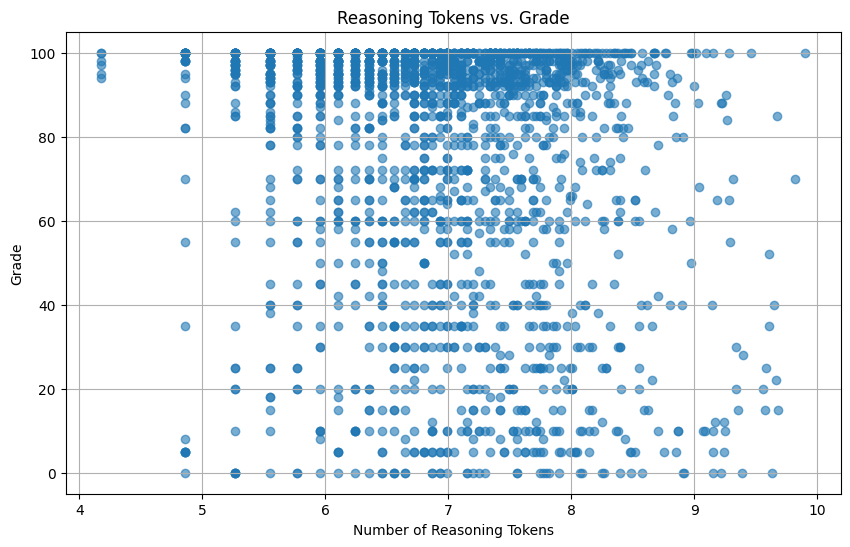

In [53]:
# draw a scatter plot of num of reasoning_tokens vs numeric grade in df_dup
# --- IGNORE ---
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
# don't map grades, use the numbers
# I said don't map
plt.scatter(np.log1p(final_df_dup['reasoning_tokens']), final_df_dup['grade'].astype(float), alpha=0.6)
plt.title('Reasoning Tokens vs. Grade')
# --- IGNORE ---
plt.xlabel('Number of Reasoning Tokens')
plt.ylabel('Grade')
plt.grid(True)
plt.show()


In [91]:
# group by df_dup by 'id' and extract for each id for reasoning tokens ad grade: the mean, the std, min and max values, median
# join the created columns back to df_with_labels on id
final_df_dup['grade'] = pd.to_numeric(final_df_dup['grade'], errors='coerce')
final_df_dup['log_reasoning_tokens'] = np.log1p(final_df_dup['reasoning_tokens'])
agg_funcs = {
    'reasoning_tokens': ['mean', 'std', 'min', 'max', 'median'],
    'log_reasoning_tokens': ['mean', 'std', 'min', 'max', 'median'],
    'grade': ['mean', 'std', 'min', 'max', 'median']
}
agg_df = final_df_dup.groupby('id').agg(agg_funcs)
agg_df.columns = ['_'.join(col).strip() for col in agg_df.columns.values]
# normalize agg_df created columns
for col in agg_df.columns:
    if 'reasoning_tokens' in col:
        agg_df[col+'_normalized'] = (agg_df[col] - agg_df[col].mean()) / agg_df[col].std()
    if 'grade' in col:
        agg_df[col+'_normalized'] = (agg_df[col] - agg_df[col].mean()) / agg_df[col].std()
final_df = df_with_labels.merge(agg_df, on='id', how='left').merge(avg_distances, on='id', how='left')
final_df['avg_answer_distance_normalized'] = (final_df['avg_answer_distance'] - final_df['avg_answer_distance'].mean()) / final_df['avg_answer_distance'].std()
final_df.head()

final_df.to_excel(OUTPUTS_DIR / "final_exams_dataset_with_aggregations.xlsx", index=False)


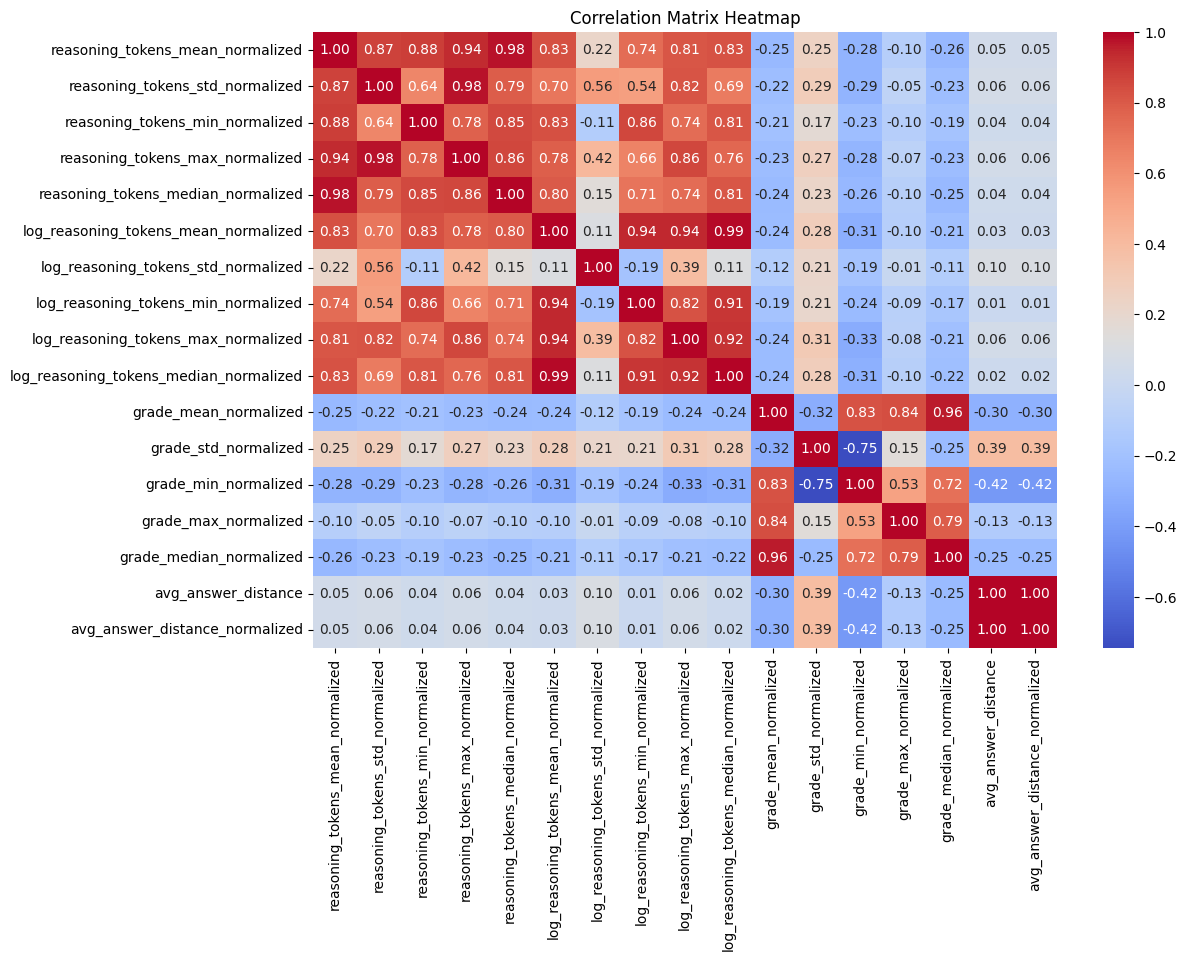

Plotting 1D scatter for column: reasoning_tokens_std_normalized


Plotting 1D scatter for column: grade_std_normalized


Plotting 1D scatter for column: log_reasoning_tokens_mean_normalized


Plotting 1D scatter for column: reasoning_tokens_mean


Plotting 1D scatter for column: grade_std


Plotting 1D scatter for column: log_reasoning_tokens_mean


Plotting 1D scatter for column: avg_answer_distance


Plotting 1D scatter for column: avg_answer_distance_normalized


In [98]:
final_df_filtered = final_df[final_df['reasoning_tokens_std_normalized'] < 0.3]
df_in_use = final_df.copy()

df_in_use['id'] = df_in_use['id'].astype(object)
agg_df['id'] = agg_df.index.astype(object)
# show correlation matrix heatmap of agg_df for all numeric columns - without id column and non normalized columns
numeric_cols = [col for col in df_in_use.select_dtypes(include=[np.number]).columns if 'normalized' in col or 'avg_answer_distance' in col]
corr_matrix = df_in_use[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

# show one dimentional scatter plots for each of the following columns: 'reasoning_tokens_std_normalized', 'grade_std_normalized', 'log_reasoning_tokens_std_normalized'
cols = [
    "reasoning_tokens_std_normalized",
    "grade_std_normalized",
    "log_reasoning_tokens_mean_normalized",
    "reasoning_tokens_mean",
    "grade_std",
    "log_reasoning_tokens_mean",
    "avg_answer_distance",
    "avg_answer_distance_normalized"
]

for col in cols:
    print(f"Plotting 1D scatter for column: {col}")
    mean_col = col.replace("std", "mean")
    std_col = col.replace("mean", "std")
    color_col = mean_col if "std" in col else std_col

    df_plot = df_in_use.copy()
    df_plot["_y"] = 0  # keep it 1D

    fig = px.scatter(
        df_plot,
        x=col,
        y="_y",
        color=color_col,
        hover_data=["id", col, color_col],
        title=f"1D scatter: {col} (colored by {color_col})",
        color_continuous_scale="Viridis",
    )

    fig.update_yaxes(visible=False)
    fig.update_layout(
        xaxis_title=col,
        yaxis_title="",
        showlegend=False,
    )

    fig.show()

In [99]:
# show percentage table of 'avg_answer_distance', 'mean_grade', 'std_grade', 'mean_reasoning_tokens', 'std_reasoning_tokens' columns in final_df
# present it as a table without changing final_df
percentage_table = final_df[[
    'avg_answer_distance',
    'reasoning_tokens_mean',
    'reasoning_tokens_std',
    'grade_mean',
    'grade_std'
]].describe().loc[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
display(percentage_table)

,avg_answer_distance,reasoning_tokens_mean,reasoning_tokens_std,grade_mean,grade_std
mean,0.182290,1637.556518,735.993391,75.073593,13.911089
std,0.081330,1667.291797,909.085388,25.788244,11.795854
min,0.027641,146.285714,34.209439,0.000000,0.000000
25%,0.132467,603.428571,212.263987,61.857143,3.287784
50%,0.157560,1152.000000,405.974430,85.285714,12.075161
75%,0.204545,1947.428571,811.107649,95.000000,21.435396
max,0.544629,11693.714286,5064.730257,100.000000,48.599432


In [100]:
final_df.to_excel(OUTPUTS_DIR / "exams_df.xlsx", index=False)